# FHI SME Challenge: Data Exploration

This notebook documents our exploratory analysis of the Zindi data.org Financial Health
Prediction Challenge dataset. The goal is to predict the Financial Health Index (FHI)
category of small and medium enterprises (SMEs) across four Southern African countries:
Eswatini, Lesotho, Zimbabwe and Malawi.

The FHI label has three ordered classes: **Low**, **Medium**, and **High**. It was
constructed from survey responses across four dimensions: savings and assets, debt and
repayment ability, resilience to shocks, and access to credit and financial services.

We work through the data section by section, documenting each finding and the decision
it led to. Some of these findings only became clear partway through the competition,
so this notebook tells the story in the order we discovered things, not in the order
the data is organised.

## Setup

We start by loading the raw training and test CSVs along with the standard libraries.
All plots are saved to the `outputs/figures/` directory.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR = Path("../data/raw")

train = pd.read_csv(RAW_DIR / "Train.csv")
test  = pd.read_csv(RAW_DIR / "Test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nColumns ({len(train.columns)}):")
for col in train.columns:
    print(f"  {col}")

Train shape: (9618, 39)
Test shape:  (2405, 38)

Columns (39):
  ID
  country
  owner_age
  attitude_stable_business_environment
  attitude_worried_shutdown
  compliance_income_tax
  perception_insurance_doesnt_cover_losses
  perception_cannot_afford_insurance
  personal_income
  business_expenses
  business_turnover
  business_age_years
  motor_vehicle_insurance
  has_mobile_money
  current_problem_cash_flow
  has_cellphone
  owner_sex
  offers_credit_to_customers
  attitude_satisfied_with_achievement
  has_credit_card
  keeps_financial_records
  perception_insurance_companies_dont_insure_businesses_like_yours
  perception_insurance_important
  has_insurance
  covid_essential_service
  attitude_more_successful_next_year
  problem_sourcing_money
  marketing_word_of_mouth
  has_loan_account
  has_internet_banking
  has_debit_card
  future_risk_theft_stock
  business_age_months
  medical_insurance
  funeral_insurance
  motivation_make_more_money
  uses_friends_family_savings
  uses_infor

The dataset has 9,618 training rows and 2,405 test rows across 37 feature columns
plus the target. The features cover demographics (owner age, sex), business characteristics
(turnover, expenses, age), financial product access (credit cards, loans, insurance),
attitudes and perceptions, and compliance behaviour.

Notice that the test set has no Target column. We need to predict that.

## 1. The Target Variable and Why Class Imbalance Matters

Before looking at features, we need to understand what we are predicting and whether
the classes are balanced. This shapes every modelling decision that follows.

In [ ]:
counts = train["Target"].value_counts().reindex(["Low", "Medium", "High"])
proportions = counts / len(train)

print("Target class counts and proportions:")
for label in ["Low", "Medium", "High"]:
    print(f"  {label:<8} {counts[label]:>5}  ({proportions[label]:.1%})")

Target class counts and proportions:
  Low       6280  (65.3%)
  Medium    2868  (29.8%)
  High       470  (4.9%)


The dataset is heavily imbalanced. Low accounts for **`65.3%`** of rows, Medium for **`29.8%`**,
and High for only **`4.9%`**.<br> 
This has an important consequence for evaluation:

- A naive model that always predicts Low would achieve 65% accuracy. That sounds<br>
reasonable but it would score zero F1 on the Medium and High classes.

- The competition uses **weighted F1**, which weights each class by its support<br>
(number of samples). This is more appropriate than macro F1 for imbalanced data<br>
because it does not penalise the model equally for errors on 470 High cases versus<br>
6,280 Low cases. Understanding this metric early was one of our most important decisions.<br>

We confirmed this through the competition forum, as the official page was ambiguous<br>
about which F1 variant was used.

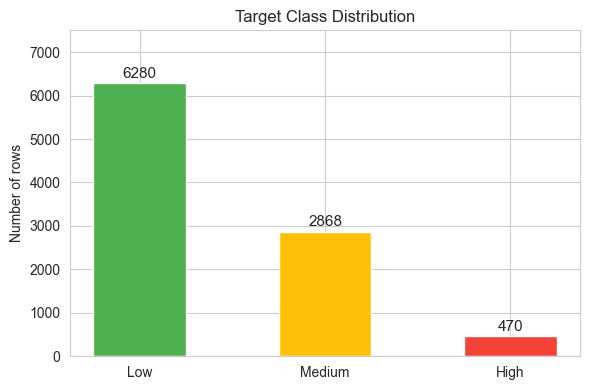

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4CAF50", "#FFC107", "#F44336"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha="center", va="bottom", fontsize=11)
ax.set_title("Target Class Distribution")
ax.set_ylabel("Number of rows")
ax.set_ylim(0, 7500)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Country-Level Differences

The dataset spans four countries. Before exploring features, we need to understand <br>
whether the countries have fundamentally different target distributions. If they do,<br>
we cannot treat this as a single homogeneous dataset.

In [ ]:
country_stats = train.groupby("country").agg(
    n=("Target", "count"),
    high_count=("Target", lambda x: (x == "High").sum()),
    medium_count=("Target", lambda x: (x == "Medium").sum()),
    low_count=("Target", lambda x: (x == "Low").sum()),
).assign(
    high_rate=lambda df: df["high_count"] / df["n"],
    medium_rate=lambda df: df["medium_count"] / df["n"],
    low_rate=lambda df: df["low_count"] / df["n"],
)

print("Per-country statistics:")
print(country_stats[["n", "high_count", "high_rate",
                      "medium_rate", "low_rate"]].round(3).to_string())

Per-country statistics:
             n  high_count  high_rate  medium_rate  low_rate
country                                                     
eswatini  2674         307     0.1150       0.3710    0.5140
lesotho   1944           6     0.0030       0.3930    0.6040
malawi    2388          96     0.0400       0.1470    0.8120
zimbabwe  2612          61     0.0230       0.2910    0.6860


The differences are stark. Eswatini has a High class rate of **`11.5%`**, while Lesotho<br>
has only **`0.3%`**, a 38-fold difference. This is not just a statistical quirk; it <br>
reflects genuinely different economic conditions and financial inclusion levels <br>
across Southern Africa.

Eswatini uses the Swazi Lilangeni (pegged to ZAR), Zimbabwe uses USD, Malawi uses<br>
the Kwacha (extremely devalued), and Lesotho uses the Loti (pegged to ZAR). This<br>
means monetary figures are in completely different scales across countries, which<br>
will become important when we look at income and turnover columns.<br>

The test set distribution across countries should mirror train if the split was<br>
stratified correctly.

In [ ]:
print("Test country distribution:")
test_country_counts = test["country"].value_counts()
train_country_pct = train["country"].value_counts(normalize=True)
test_country_pct  = test["country"].value_counts(normalize=True)

for country in sorted(train["country"].unique()):
    print(f"  {country:<12}  train={train_country_pct[country]:.1%}  "
          f"test={test_country_pct[country]:.1%}")

Test country distribution:
  eswatini      train=27.8%  test=27.8%
  lesotho       train=20.2%  test=20.2%
  malawi        train=24.8%  test=24.8%
  zimbabwe      train=27.2%  test=27.2%


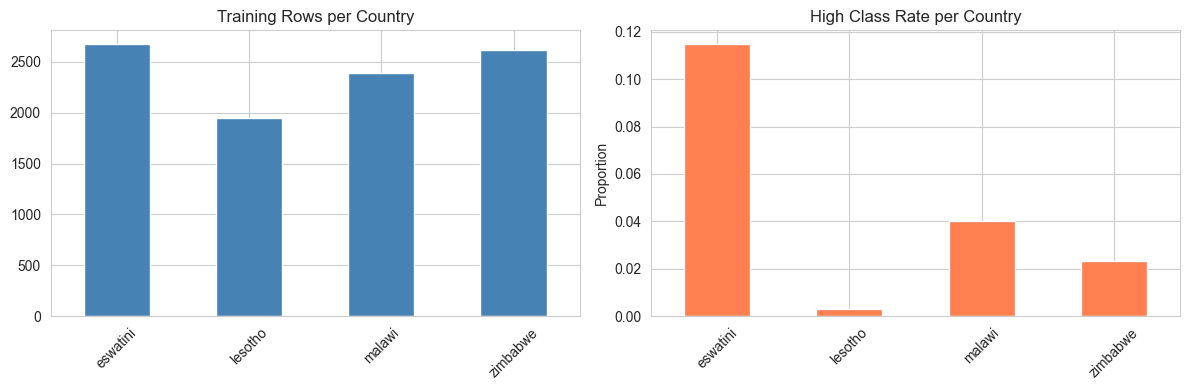

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

country_stats["n"].plot(kind="bar", ax=axes[0],
                        color="steelblue", edgecolor="white")
axes[0].set_title("Training Rows per Country")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

country_stats["high_rate"].plot(kind="bar", ax=axes[1],
                                color="coral", edgecolor="white")
axes[1].set_title("High Class Rate per Country")
axes[1].set_xlabel("")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "country_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

The country split in the test set roughly matches training, which is good. There
is no obvious distribution shift at the country level.

The low High rate in Lesotho (**`0.3%`**, just 6 cases in 1,944 rows) will become a <br>
recurring theme. Any model that gets a single Lesotho High case wrong incurs <br>
a significant penalty, but there are so few cases that the model has almost no <br>
signal to learn from. This creates a hard performance ceiling for the overall <br>
weighted F1.

In [ ]:
miss = train.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(f"Columns with missing values: {len(miss)} out of {len(train.columns)}")
print()
print(miss.round(3).to_string())

Columns with missing values: 35 out of 39

uses_informal_lender                                               0.4670
uses_friends_family_savings                                        0.4670
motivation_make_more_money                                         0.4460
funeral_insurance                                                  0.4350
medical_insurance                                                  0.4350
business_age_months                                                0.4270
future_risk_theft_stock                                            0.4260
has_debit_card                                                     0.4160
has_internet_banking                                               0.4160
has_loan_account                                                   0.4160
current_problem_cash_flow                                          0.3930
marketing_word_of_mouth                                            0.3840
problem_sourcing_money                                             0.

Several columns are missing **`20%`** of values. The pattern is suspicious, the same <br>
percentage (about **`20%`**) appears across many columns simultaneously. This suggests <br>
a block of survey questions that were not administered in one country. <br>

To investigate, we need to look at missingness conditional on country.

In [ ]:
# Check missingness rates per country for the 20%-missing columns
suspicious_cols = miss[miss.between(0.19, 0.22)].index.tolist()

print("Missingness by country for the ~20%-missing columns:")
print()
for col in suspicious_cols:
    rates = train.groupby("country")[col].apply(lambda x: x.isnull().mean())
    print(f"{col}:")
    for country, rate in rates.items():
        marker = "  <-- 100% MISSING (structural absence)" if rate >= 0.999 else ""
        print(f"  {country:<12} {rate:.1%}{marker}")
    print()

Missingness by country for the ~20%-missing columns:

has_insurance:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.3%
  zimbabwe     0.1%

perception_insurance_important:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.3%
  zimbabwe     0.1%

keeps_financial_records:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.0%
  zimbabwe     0.2%

perception_insurance_companies_dont_insure_businesses_like_yours:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.0%
  zimbabwe     0.1%

has_credit_card:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.0%
  zimbabwe     0.1%

attitude_satisfied_with_achievement:
  eswatini     0.0%
  lesotho      100.0%  <-- 100% MISSING (structural absence)
  malawi       0.0%
  zimbabwe     0.1%

offers_credit_to_custo

This is a major finding. Every one of these columns is exactly `100%` missing <br>
for Lesotho and 0% missing for the other three countries. This is not non-response<br>
or Don't know answers. These questions were simply never asked in the Lesotho<br>
survey instrument.

In other words, Lesotho used a different version of the questionnaire. The<br>
11 affected columns include some of the strongest predictors of financial health:
- keeps_financial_records, 
- has_credit_card, 
- has_insurance, 
- medical_insurance,
- funeral_insurance, and 
- offers_credit_to_customers.

This has two consequences:
1. Lesotho rows are information-starved. The model has far less signal to work with.
2. We must encode these missing values as "structurally absent" (instrument not administered)<br>
   rather than "respondent declined to answer". They are semantically different.

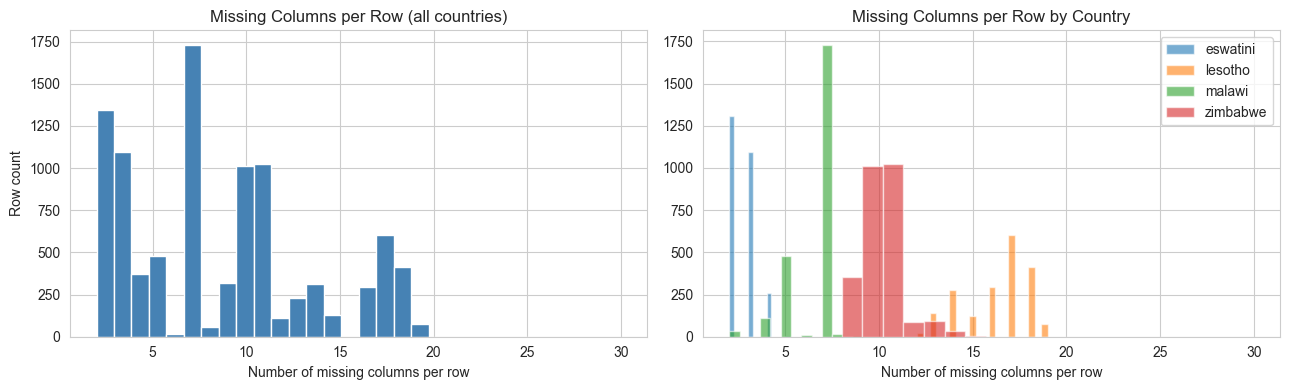

In [ ]:
# Visualise per-row missing count -- should show clear bimodal distribution
train_miss_count = train.isnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_miss_count, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Missing Columns per Row (all countries)")
axes[0].set_xlabel("Number of missing columns per row")
axes[0].set_ylabel("Row count")

for country in sorted(train["country"].unique()):
    mask = train["country"] == country
    vals = train_miss_count[mask]
    axes[1].hist(vals, bins=20, alpha=0.6, label=country, edgecolor="white")
axes[1].set_title("Missing Columns per Row by Country")
axes[1].set_xlabel("Number of missing columns per row")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "missingness_by_row.png", dpi=120, bbox_inches="tight")
plt.show()

The bimodal distribution confirms the structural split. Lesotho rows cluster around<br>
12 missing columns per row while all other country rows cluster near zero. There is<br>
no ambiguity, this is a clean instrument boundary.

We can also visualise this as a heatmap to see which specific columns are affected.

C:\Users\gwach\AppData\Local\Temp\ipykernel_46708\1055120272.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  miss_by_country = train.groupby("country").apply(lambda g: g.isnull().mean())


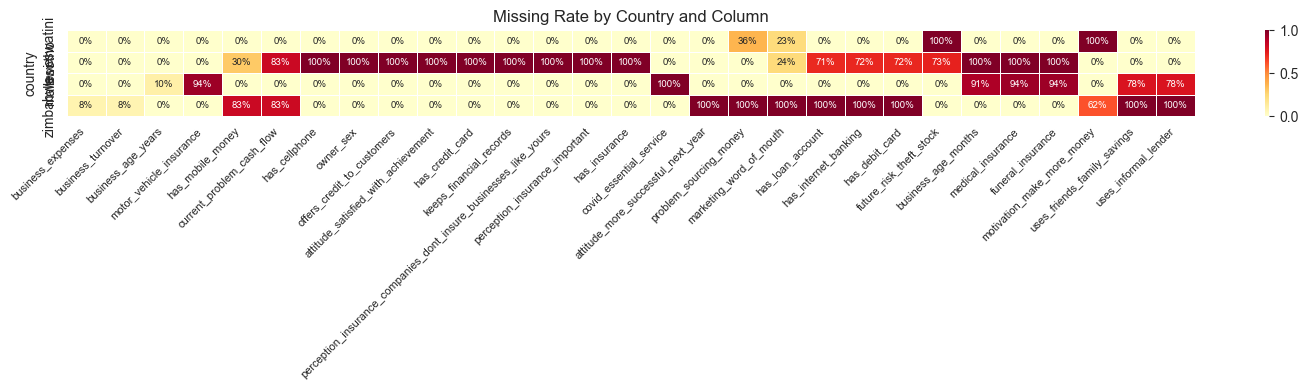

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
miss_by_country = train.groupby("country").apply(lambda g: g.isnull().mean())
# Only show columns with meaningful missingness
miss_by_country = miss_by_country.loc[:, miss_by_country.max() > 0.05]
sns.heatmap(miss_by_country, annot=True, fmt=".0%", cmap="YlOrRd",
            ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Missing Rate by Country and Column")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missingness_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

The heatmap makes it clear: 

- the red block of 100% missingness is exclusively Lesotho
- the affected columns are a coherent set of financial access and <br>
record-keeping questions. 
- all other country-column combinations are either fully <br>
present or show modest non-response (not structural absence).

## 4. Encoding Issues: Unicode Variants

When loading the raw CSV, several categorical columns appeared to have more unique<br>
values than expected. Looking closely at the perception and attitude columns revealed<br>
a data quality issue: the same response (such as `"Don't know"`) appears in multiple<br>
forms due to unicode character corruption that likely occurred during data collection<br>
or export.

This matters because if we treat these as separate categories, the model learns nothing<br>
useful from them, each variant appears too rarely to build reliable splits.

In [ ]:
# Show the raw unicode variants in one affected column
print("Raw unique values in perception_insurance_important:")
print("(showing both the display form and the unicode escape form)\n")
for v in sorted(train["perception_insurance_important"].dropna().unique()):
    print(f"  display:  {v}")
    print(f"  escaped:  {v.encode('unicode_escape').decode()}")
    print()

Raw unique values in perception_insurance_important:
(showing both the display form and the unicode escape form)

  display:   Do not know / N‎/A
  escaped:   Do not know / N\u200e/A

  display:  Don't Know
  escaped:  Don't Know

  display:  Don?t know / doesn?t apply
  escaped:  Don?t know / doesn?t apply

  display:  No
  escaped:  No

  display:  Yes
  escaped:  Yes



You can see multiple variants of `"Don't know"` that look identical on screen<br>
but are different byte sequences. The question mark character and the unicode<br>
right-single-quotation mark (U+2019) are being used interchangeably, and there<br>
are also invisible characters like the left-to-right mark (U+200E).<br>

The fix is NFKC unicode normalisation, which converts all of these to a<br>
canonical form before any further processing. We apply this as the first step<br>
in our preprocessing pipeline.

In [35]:
def normalise_string(val):
    if pd.isna(val):
        return np.nan
    return (
        unicodedata.normalize("NFKC", str(val))
        .strip().lower()
        .replace("\u2019", "'")
        .replace("\u200e", "")
        .replace("?", "'")
    )

print("Effect of NFKC normalisation on unique value counts:\n")
print(f"  {'Column':<67} {'Before':>8} {'After':>7} {'Collapsed':>10}")
print("  " + "-" * 100)
for col in train.select_dtypes("object").columns:
    if col in ["ID", "Target", "country"]:
        continue
    n_before = train[col].dropna().nunique()
    n_after  = train[col].dropna().apply(normalise_string).nunique()
    if n_before != n_after:
        print(f"  {col:<65} {n_before:>8} {n_after:>7} {n_before-n_after:>10}")

Effect of NFKC normalisation on unique value counts:

  Column                                                                Before   After  Collapsed
  ----------------------------------------------------------------------------------------------------
  has_mobile_money                                                         5       4          1
  has_credit_card                                                          5       4          1
  perception_insurance_companies_dont_insure_businesses_like_yours         5       4          1
  has_loan_account                                                         6       5          1
  has_internet_banking                                                     6       5          1
  has_debit_card                                                           5       4          1
  medical_insurance                                                        6       5          1
  funeral_insurance                                                      

Every column where the count dropped was affected by unicode variants of the<br>
same response. After normalisation these collapse to the correct number of<br>
distinct answers. This was one of the techniques used by the top solution in<br>
the competition, and explains why their ensemble weights shifted significantly<br>
toward CatBoost once the cleaning was applied. CatBoost's categorical handling<br>
benefits from clean, consistent category strings.

## 5. Financial Product Columns: What NaN Really Means

Ten columns follow a three-level pattern: `"Have now"`, `"Used to have"`, `"Never had"`.<br>
These represent financial product access: insurance types, bank accounts, mobile<br>
money, loan accounts, and informal savings mechanisms.

A large proportion of these columns are missing (NaN). We need to decide what<br>
that NaN means before we can model with them.

In [ ]:
product_cols = [
    "motor_vehicle_insurance", "has_mobile_money", "has_credit_card",
    "has_loan_account", "has_internet_banking", "has_debit_card",
    "medical_insurance", "funeral_insurance",
    "uses_friends_family_savings", "uses_informal_lender"
]

print("Missing rate and High class rate by response value for product columns:\n")
for col in product_cols:
    nan_count = train[col].isna().sum()
    nan_pct   = nan_count / len(train)
    print(f"{col}  (NaN: {nan_count} rows, {nan_pct:.1%}):")
    rates = train.groupby(col, dropna=False)["Target"].apply(
        lambda x: (x == "High").mean()
    )
    counts = train[col].value_counts(dropna=False)
    for val, rate in rates.sort_values(ascending=False).items():
        n = counts.get(val, 0)
        label = "NaN" if pd.isna(val) else str(val)
        print(f"  {label:<25} High rate = {rate:.1%}   (n={n})")
    print()

Missing rate and High class rate by response value for product columns:

motor_vehicle_insurance  (NaN: 2244 rows, 23.3%):
  Have now                  High rate = 31.0%   (n=297)
  Used to have but don’t have now High rate = 23.4%   (n=47)
  Never had                 High rate = 4.6%   (n=6994)
  NaN                       High rate = 1.9%   (n=2244)
  Don't know                High rate = 0.0%   (n=36)

has_mobile_money  (NaN: 2751 rows, 28.6%):
  Used to have but don’t have now High rate = 8.2%   (n=61)
  Have now                  High rate = 7.0%   (n=4876)
  Used to have but don't have now High rate = 4.9%   (n=82)
  Never had                 High rate = 4.5%   (n=1842)
  NaN                       High rate = 1.3%   (n=2751)
  Don't know                High rate = 0.0%   (n=6)

has_credit_card  (NaN: 1947 rows, 20.2%):
  Have now                  High rate = 56.2%   (n=281)
  Used to have but don’t have now High rate = 17.6%   (n=17)
  Don't know                High rate = 5.7%   (n

The pattern is consistent across every product column: rows where the value is<br> 
NaN have a much lower High rate than rows where the respondent said `"Never had"`.<br>
This is counterintuitive at first, you might expect `NaN` and `"Never had"` to be<br>
the same thing but looking at it from a survey design perspective it makes sense.

If a business owner has internet banking, they would answer the question. If they<br>
have no internet banking, they would say `"Never had"`. The `NaN` cases are people who<br>
did not engage with the question at all. In the context of this survey, that<br>
effectively means they have never had the product so the silence is itself an answer.

This is a domain knowledge decision, not a purely statistical one. We impute `NaN`
in these product columns as 0 (representing `"Never had"` in our ordinal encoding).<br>
This was the largest single improvement in the entire project, adding approximately<br>
0.04 to our OOF weighted F1.

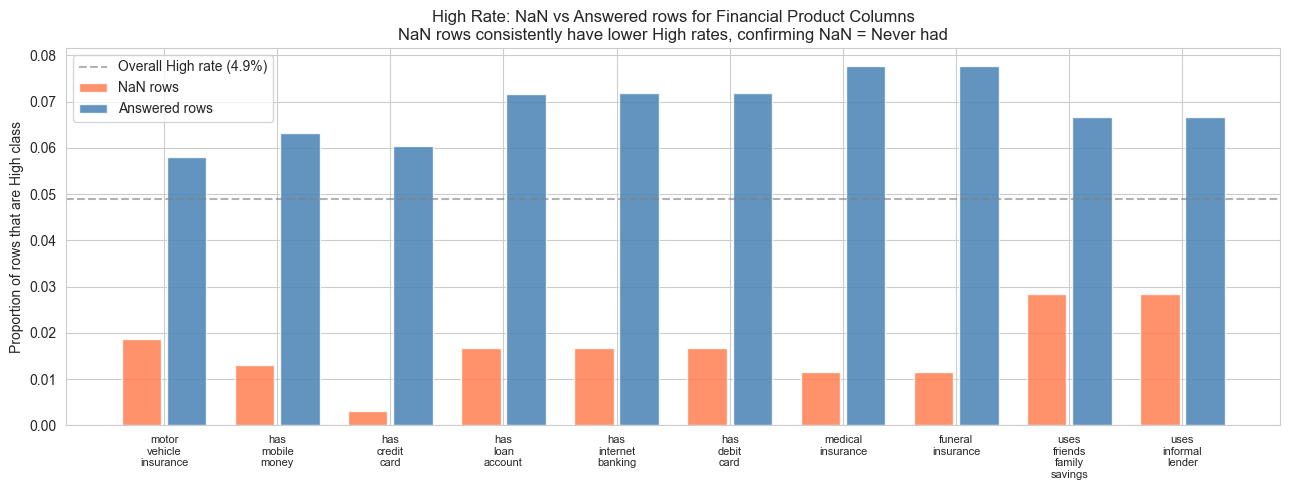

In [14]:
# Visualise the NaN vs answered High rates clearly
nan_high_rates    = []
answer_high_rates = []

for col in product_cols:
    nan_mask  = train[col].isna()
    nan_rate  = (train.loc[nan_mask,  "Target"] == "High").mean()
    ans_rate  = (train.loc[~nan_mask, "Target"] == "High").mean()
    nan_high_rates.append(nan_rate)
    answer_high_rates.append(ans_rate)

x = np.arange(len(product_cols))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, nan_high_rates,    0.35, label="NaN rows",
       color="coral", alpha=0.85, edgecolor="white")
ax.bar(x + 0.2, answer_high_rates, 0.35, label="Answered rows",
       color="steelblue", alpha=0.85, edgecolor="white")
ax.axhline(train["Target"].eq("High").mean(), color="gray",
           linestyle="--", alpha=0.6, label="Overall High rate (4.9%)")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in product_cols],
                   fontsize=8)
ax.set_ylabel("Proportion of rows that are High class")
ax.set_title("High Rate: NaN vs Answered rows for Financial Product Columns\n"
             "NaN rows consistently have lower High rates, confirming NaN = Never had")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "product_nan_rates.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. The NaN Reversal: When Silence Means Something Else

Encouraged by the product column finding, we checked all binary and indicator
columns for the same pattern. What we found was a warning: not all NaN values
mean absence. Some columns show the exact opposite pattern.

In [44]:
binary_cols = [
    "has_cellphone", "has_insurance", "future_risk_theft_stock",
    "problem_sourcing_money", "marketing_word_of_mouth",
    "motivation_make_more_money", "covid_essential_service",
    "current_problem_cash_flow"
]

print("NaN direction check for binary/indicator columns:\n")
print(f"  {'Column':<30} {'NaN High%':>10} {'Answered High%':>15} {'Signal':>12}")
print("  " + "-" * 92)

for col in binary_cols:
    nan_mask = train[col].isna()
    if nan_mask.sum() == 0:
        continue
    nan_rate = (train.loc[nan_mask,  "Target"] == "High").mean()
    ans_rate = (train.loc[~nan_mask, "Target"] == "High").mean()
    direction = "REVERSAL" if nan_rate > ans_rate + 0.01 else "normal"
    print(f"  {col:<30} {nan_rate:>10.1%} {ans_rate:>15.1%} {direction:>12}")

NaN direction check for binary/indicator columns:

  Column                          NaN High%  Answered High%       Signal
  --------------------------------------------------------------------------------------------
  has_cellphone                        0.3%            6.0%       normal
  has_insurance                        0.4%            6.0%       normal
  future_risk_theft_stock              7.6%            2.9%     REVERSAL
  problem_sourcing_money               4.2%            5.3%       normal
  marketing_word_of_mouth              3.4%            5.8%       normal
  motivation_make_more_money           8.2%            2.2%     REVERSAL
  covid_essential_service              4.0%            5.2%       normal
  current_problem_cash_flow            1.6%            7.0%       normal


The two columns showing reversal `future_risk_theft_stock` and<br>
`motivation_make_more_money` have `NaN` rows with a **`7.6%`** and **`8.2%`** High rate<br>
respectively, compared to only 2.9% and 2.2% for answered rows.

Why would `NaN` rows have a higher High rate? The most likely explanation is that<br>
these columns are part of the Lesotho structural absence block, and the Lesotho<br>
rows that do exist in the High class are different in some way from what you would<br>
expect. There may also be a correlation with Eswatini's higher High rate.<br>
Eswatini may have different non-response patterns for these specific questions.

The key takeaway is that we must not blindly apply the `"NaN = absence"` rule.<br>
Each column's `NaN` semantics needs to be verified before imputing. For these two<br>
columns, imputing `NaN` as 0 would destroy signal and potentially hurt performance.

## 7. Key Categorical Predictors

Beyond the product columns, two categorical features stood out early as having
strong relationships with the target: `compliance_income_tax` and
`keeps_financial_records`. These both relate to business formality and financial
discipline, which maps directly to the FHI framework.

In [16]:
for col in ["compliance_income_tax", "keeps_financial_records"]:
    print(f"{col}:")
    print(f"  (NaN count: {train[col].isna().sum()})")
    rates  = train.groupby(col, dropna=False)["Target"].apply(
        lambda x: (x == "High").mean()
    ).sort_values(ascending=False)
    counts = train[col].value_counts(dropna=False)
    for val, rate in rates.items():
        n   = counts.get(val, 0)
        bar = "#" * int(rate * 200)
        print(f"  {str(val):<35} {rate:.1%}  {bar}  (n={n})")
    print()

compliance_income_tax:
  (NaN count: 4)
  Yes                                 16.8%  #################################  (n=1252)
  No                                  3.2%  ######  (n=8010)
  Don’t know                          1.8%  ###  (n=341)
  Refused                             0.0%    (n=11)
  nan                                 0.0%    (n=4)

keeps_financial_records:
  (NaN count: 1949)
  Yes, always                         15.3%  ##############################  (n=1525)
  Yes                                 7.1%  ##############  (n=1139)
  Yes, sometimes                      4.8%  #########  (n=1671)
  No                                  2.0%  ####  (n=3334)
  nan                                 0.3%    (n=1949)



Both columns show a clear gradient. For `compliance_income_tax`, businesses
that pay income tax have a 16.8% High rate versus 2.9% for non-compliant businesses.
For `keeps_financial_records`, businesses that always keep records have a 15.3%
High rate versus 3.6% for those that never keep records.

This makes intuitive sense: businesses that are tax-compliant and keep financial
records are more formally integrated into the economy, which is one of the core
dimensions the FHI measures.

An important modelling note: we encode these as ordinal integers (0, 1, 2, 3 for
keeps_financial_records) because the ordering is meaningful. However, when we later
ran permutation importance on held-out folds, these columns showed near-zero
importance in the LightGBM model. This turned out to be because LightGBM was
treating them as numeric threshold features, not using the categorical split
optimisation. This is something to address in future iterations.

In [17]:
# Cross-tabulation: what happens when a business is BOTH compliant AND keeps records?
compliant = train["compliance_income_tax"] == "Yes"
records   = train["keeps_financial_records"].isin(["Yes, always", "Yes, sometimes"])

groups = {
    "Compliant AND keeps records": compliant & records,
    "Compliant only (no records)": compliant & ~records,
    "Records only (not compliant)": ~compliant & records,
    "Neither":                      ~compliant & ~records,
}

print("High rate by compliance x record-keeping combination:\n")
for label, mask in groups.items():
    subset    = train[mask]
    high_rate = (subset["Target"] == "High").mean()
    bar       = "#" * int(high_rate * 200)
    print(f"  {label:<40} {high_rate:.1%}  {bar}  (n={mask.sum()})")

High rate by compliance x record-keeping combination:

  Compliant AND keeps records              20.8%  #########################################  (n=734)
  Compliant only (no records)              11.0%  ######################  (n=518)
  Records only (not compliant)             6.6%  #############  (n=2462)
  Neither                                  1.7%  ###  (n=5904)


The combination of both behaviours produces a higher High rate than either alone,
confirming that these two features interact. A business that both pays taxes and
keeps records is sending multiple signals of financial formality simultaneously.

## 8. Attitude and Perception Columns: Less Signal Than Expected

The survey includes several questions about owner attitudes and perceptions toward
insurance and business outlook. Intuitively these seem like they should relate to
financial health. We explored them to see how much signal they actually carry.

In [18]:
attitude_cols = [
    "attitude_stable_business_environment",
    "attitude_worried_shutdown",
    "attitude_satisfied_with_achievement",
    "attitude_more_successful_next_year",
    "perception_insurance_doesnt_cover_losses",
    "perception_cannot_afford_insurance",
    "perception_insurance_important"
]

print("High rate by attitude/perception response value:\n")
for col in attitude_cols:
    normalised = train[col].apply(normalise_string)
    unique_vals = normalised.dropna().unique()
    print(f"{col}:  ({train[col].isna().sum()} missing)")
    for val in sorted(unique_vals):
        mask = normalised == val
        rate = (train.loc[mask, "Target"] == "High").mean()
        n    = mask.sum()
        bar  = "#" * int(rate * 200)
        print(f"  {str(val):<35} {rate:.1%}  {bar}  (n={n})")
    print()

High rate by attitude/perception response value:

attitude_stable_business_environment:  (2 missing)
  don't know or n/a                   3.6%  #######  (n=1345)
  no                                  4.7%  #########  (n=2451)
  yes                                 5.2%  ##########  (n=5820)

attitude_worried_shutdown:  (2 missing)
  don't know or n/a                   5.1%  ##########  (n=237)
  no                                  5.3%  ##########  (n=5804)
  yes                                 4.3%  ########  (n=3575)

attitude_satisfied_with_achievement:  (1946 missing)
  don't know                          4.5%  #########  (n=22)
  don't know or n/a                   0.0%    (n=6)
  no                                  6.1%  ############  (n=3481)
  yes                                 6.0%  ###########  (n=4163)

attitude_more_successful_next_year:  (2612 missing)
  don't know                          1.6%  ###  (n=387)
  don't know or n/a                   5.0%  ##########  (n=20)
 

The attitude and perception columns show relatively weak signal compared to
the product and compliance columns. The High rates across different response
values are often similar (within 2-3 percentage points of each other).

This is likely because these questions suffer from response bias -- financially
healthy and unhealthy businesses might both say they think insurance is important,
for different reasons. The objective financial access and product columns are
more reliable signals.

Later in our modelling work, permutation importance on held-out folds confirmed
this: attitude columns scored near zero. They are encoded and included in the
model but contribute minimal predictive power.

## 9. The Strongest Known Interaction

While exploring the data, we noticed an interaction between `has_insurance` and
`has_credit_card` that appeared unusually strong. We investigated it directly.

In [19]:
mask_both    = (train["has_insurance"] == "Yes") & (train["has_credit_card"] == "Have now")
mask_ins     = (train["has_insurance"] == "Yes") & (train["has_credit_card"] != "Have now")
mask_card    = (train["has_insurance"] != "Yes") & (train["has_credit_card"] == "Have now")
mask_neither = (train["has_insurance"] != "Yes") & (train["has_credit_card"] != "Have now")

groups = [
    ("Insurance=Yes AND CreditCard=Have now", mask_both),
    ("Insurance=Yes, no current credit card", mask_ins),
    ("Credit card only, no insurance",        mask_card),
    ("Neither",                               mask_neither),
]

print("High rate by insurance + credit card combination:\n")
for label, mask in groups:
    subset    = train[mask]
    high_rate = (subset["Target"] == "High").mean()
    bar       = "#" * int(high_rate * 100)
    print(f"  {label:<48} {high_rate:.1%}  {bar}  (n={len(subset)})")

High rate by insurance + credit card combination:

  Insurance=Yes AND CreditCard=Have now            100.0%  ####################################################################################################  (n=51)
  Insurance=Yes, no current credit card            22.0%  ######################  (n=236)
  Credit card only, no insurance                   46.5%  ##############################################  (n=230)
  Neither                                          2.9%  ##  (n=9101)


The businesses that have both insurance AND a current credit card account have
an extremely high rate of being in the High class. This interaction makes domain
sense: having both formal insurance and a credit card simultaneously signals
a level of financial formality and access that very few SMEs in this dataset achieve.

We encoded this interaction explicitly as a feature (`insured_with_credit_card`)
rather than relying on the model to discover it, because the sample size for
this group is small and tree models might not find the split reliably on their own.

## 10. Monetary Columns: Currency Scale Differences

The dataset includes personal income, business turnover, and business expenses.
These are recorded in each country's local currency. Before using them in a
model that pools all four countries together, we need to understand whether
the scales are comparable.

In [20]:
for col in ["personal_income", "business_turnover", "business_expenses"]:
    print(f"{col} -- median by country:")
    medians = train.groupby("country")[col].median().sort_values(ascending=False)
    for country, median in medians.items():
        print(f"  {country:<12} {median:>12,.0f}")
    print()

personal_income -- median by country:
  malawi            270,000
  eswatini            2,000
  lesotho             1,500
  zimbabwe              150

business_turnover -- median by country:
  malawi            600,000
  eswatini            7,000
  zimbabwe            3,000
  lesotho             1,000

business_expenses -- median by country:
  malawi            150,000
  eswatini            3,500
  zimbabwe            1,200
  lesotho               500



The median values differ by several orders of magnitude across countries.
Malawi's Kwacha has undergone significant devaluation, so turnover figures
in the hundreds of thousands of MWK are not comparable to similar figures
in Eswatini's Lilangeni or Zimbabwe's USD.

If we feed raw monetary values into a model, the model will learn that high
numeric values correlate with Malawi specifically (since their currency
amounts are larger in nominal terms), creating a spurious country proxy.

Our solution is to compute within-country percentile ranks: instead of
"this business has turnover 500,000," we compute "this business is at the
85th percentile for turnover within its country." This makes the values
comparable across countries without needing exchange rates.

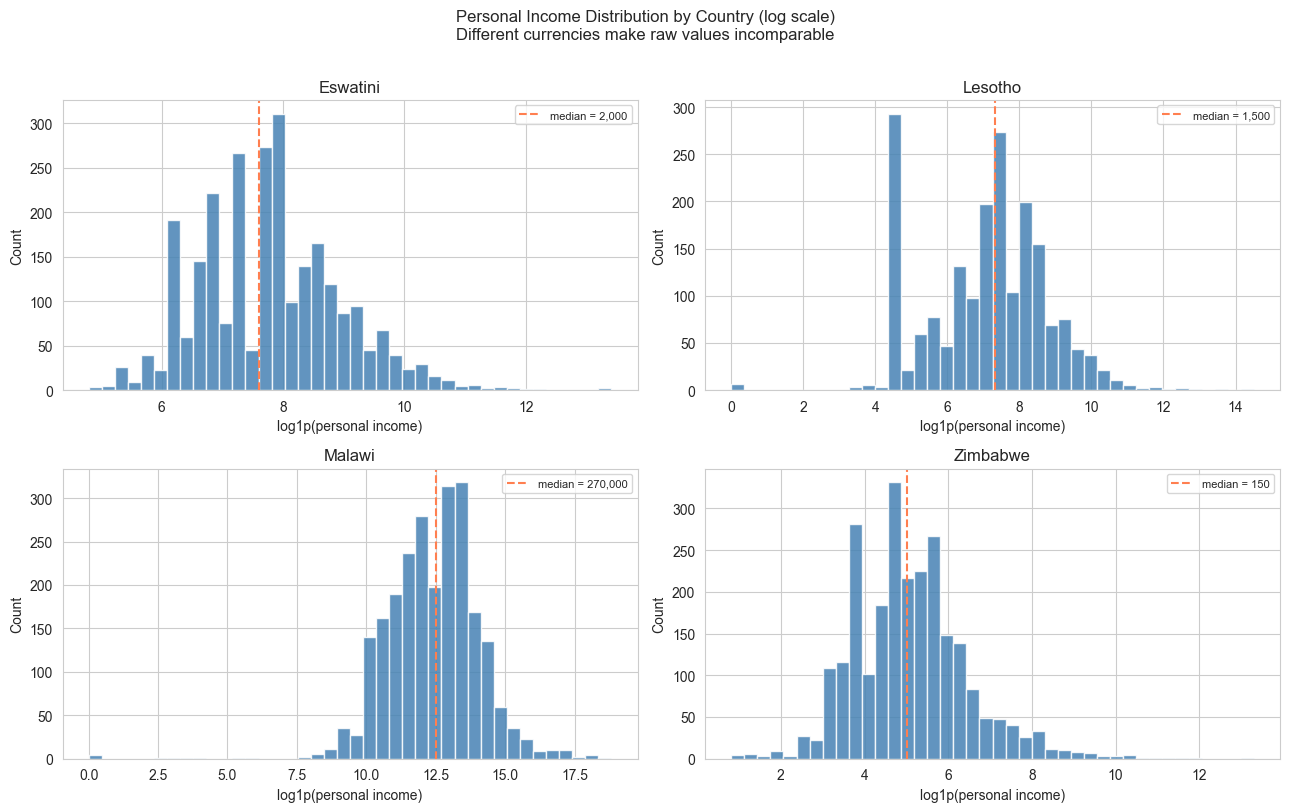

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
countries = sorted(train["country"].unique())

for ax, country in zip(axes.flat, countries):
    data = train[train["country"] == country]["personal_income"].dropna()
    ax.hist(np.log1p(data), bins=40, color="steelblue",
            edgecolor="white", alpha=0.85)
    median_log = np.log1p(data.median())
    ax.axvline(median_log, color="coral", linestyle="--", linewidth=1.5,
               label=f"median = {data.median():,.0f}")
    ax.set_title(f"{country.title()}")
    ax.set_xlabel("log1p(personal income)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Personal Income Distribution by Country (log scale)\n"
             "Different currencies make raw values incomparable",
             y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "income_by_country.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Age Variables

The dataset includes owner age (in years) and business age (in years and months
separately). We explore whether these carry useful signal and how their
distributions relate to the target classes.

In [22]:
# Combine business age years and months into total months
biz_age_months = (train["business_age_years"].fillna(0) * 12
                  + train["business_age_months"].fillna(0))

print("Owner age summary by target class:")
print(train.groupby("Target")["owner_age"].describe(
    percentiles=[0.25, 0.5, 0.75]
)[["count", "25%", "50%", "75%", "mean"]].round(1))

print("\nBusiness age (total months) summary by target class:")
biz_age_df = biz_age_months.rename("biz_age_months")
summary = pd.concat([train["Target"], biz_age_df], axis=1)
print(summary.groupby("Target")["biz_age_months"].describe(
    percentiles=[0.25, 0.5, 0.75]
)[["count", "25%", "50%", "75%", "mean"]].round(1))

Owner age summary by target class:
           count     25%     50%     75%    mean
Target                                          
High    470.0000 36.0000 42.0000 52.8000 44.6000
Low    6280.0000 31.0000 39.0000 49.0000 40.7000
Medium 2868.0000 34.0000 42.0000 52.0000 43.4000

Business age (total months) summary by target class:
           count     25%     50%      75%    mean
Target                                           
High    470.0000 38.0000 65.5000 131.0000 98.9000
Low    6280.0000 24.0000 48.0000 120.0000 83.5000
Medium 2868.0000 24.0000 55.5000 120.0000 83.5000


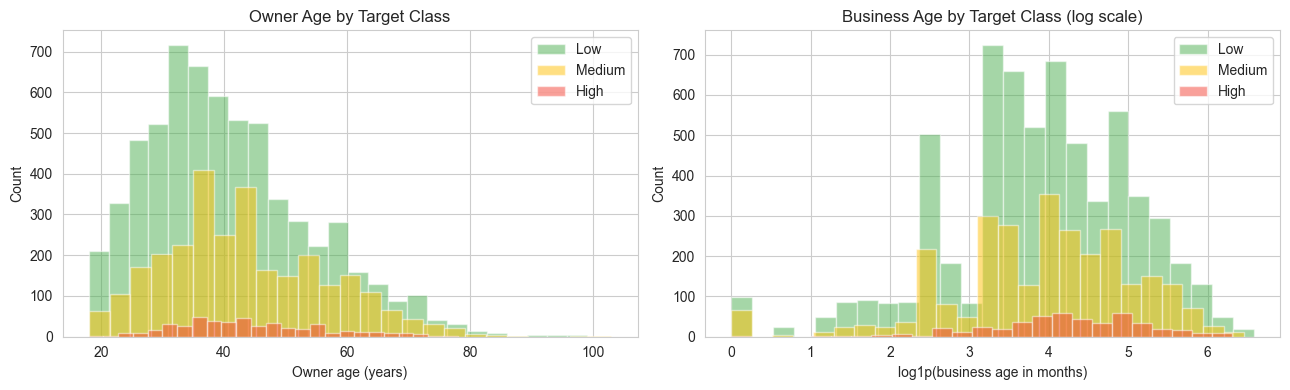

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {"Low": "#4CAF50", "Medium": "#FFC107", "High": "#F44336"}

for label, color in palette.items():
    data = train[train["Target"] == label]["owner_age"].dropna()
    axes[0].hist(data, bins=25, alpha=0.5, color=color,
                 label=label, edgecolor="white")
axes[0].set_title("Owner Age by Target Class")
axes[0].set_xlabel("Owner age (years)")
axes[0].set_ylabel("Count")
axes[0].legend()

for label, color in palette.items():
    mask = train["Target"] == label
    data = biz_age_months[mask]
    axes[1].hist(np.log1p(data), bins=25, alpha=0.5, color=color,
                 label=label, edgecolor="white")
axes[1].set_title("Business Age by Target Class (log scale)")
axes[1].set_xlabel("log1p(business age in months)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

The age distributions overlap substantially across target classes. There is no
obvious age threshold that separates High from Low businesses. Older businesses
tend to cluster slightly higher in the Medium and High categories, which makes
sense -- a business that has survived longer has demonstrated some resilience.

We include both owner age and business age as features with log transforms to
compress the long tails, but they are not among the top predictors.

## 12. Train vs Test Distribution Check

Before finalising our preprocessing approach, we check whether the test set
feature distributions look similar to the training set. Large differences would
suggest the model trained on train may not generalise well to test.

In [24]:
check_cols = [
    "country", "compliance_income_tax", "keeps_financial_records",
    "has_insurance", "motor_vehicle_insurance"
]

print("Train vs Test distribution comparison:\n")
for col in check_cols:
    train_dist = train[col].value_counts(normalize=True).round(3)
    test_dist  = test[col].value_counts(normalize=True).round(3)
    all_vals   = sorted(set(train_dist.index) | set(test_dist.index),
                        key=lambda x: str(x))
    print(f"{col}:")
    for val in all_vals:
        t_rate  = train_dist.get(val, 0.0)
        te_rate = test_dist.get(val, 0.0)
        diff    = te_rate - t_rate
        flag    = "  <-- shift >3%" if abs(diff) > 0.03 else ""
        print(f"  {str(val):<35} train={t_rate:.3f}  test={te_rate:.3f}  diff={diff:+.3f}{flag}")
    print()

Train vs Test distribution comparison:

country:
  eswatini                            train=0.278  test=0.278  diff=+0.000
  lesotho                             train=0.202  test=0.202  diff=+0.000
  malawi                              train=0.248  test=0.248  diff=+0.000
  zimbabwe                            train=0.272  test=0.272  diff=+0.000

compliance_income_tax:
  Don’t know                          train=0.035  test=0.035  diff=+0.000
  No                                  train=0.833  test=0.826  diff=-0.007
  Refused                             train=0.001  test=0.001  diff=+0.000
  Yes                                 train=0.130  test=0.138  diff=+0.008

keeps_financial_records:
  No                                  train=0.435  test=0.427  diff=-0.008
  Yes                                 train=0.149  test=0.153  diff=+0.004
  Yes, always                         train=0.199  test=0.198  diff=-0.001
  Yes, sometimes                      train=0.218  test=0.221  diff=+0.003



The train and test distributions are closely aligned across all checked columns.
There is no evidence of meaningful distribution shift between the two sets,
which gives us confidence that a model trained on train will generalise
to the test set at prediction time.

## Summary of Key Findings

Here we collect every insight from this exploration and the decision each one led to.

**Finding 1: Severe class imbalance**
High is only 4.9% of training rows. A naive model could achieve 65% accuracy
by always predicting Low. We use weighted F1 as the evaluation metric, which
correctly weights each class by its support.

**Finding 2: Radically different High rates per country**
Eswatini has 11.5% High, Lesotho has 0.3%. These countries are fundamentally
different in financial inclusion levels. The multi-country structure shapes
almost every feature engineering and validation decision.

**Finding 3: Lesotho uses a different survey instrument**
Eleven columns are 100% structurally absent for all Lesotho rows. This is not
non-response -- these questions were never asked. This creates a hard ceiling
on Lesotho's predictability (~0.72 OOF regardless of approach) and means 20%
of the training data is information-starved.

**Finding 4: NaN in product columns means Never had**
Financial product NaN rows consistently have lower High rates than rows where
respondents answered "Never had". Imputing product NaN as 0 (Never had) was
our largest single improvement: approximately +0.04 OOF weighted F1.

**Finding 5: NaN reversal for some indicator columns**
future_risk_theft_stock and motivation_make_more_money show the opposite pattern:
NaN rows have higher High rates than answered rows. These NaN values should NOT
be imputed as 0 -- they carry a different kind of information.

**Finding 6: Unicode variants create false categories**
Perception and attitude columns contain multiple byte-level variants of the same
response due to data collection corruption. NFKC normalisation collapses these
to canonical form, which changed our ensemble weights from LGB=0.90/CAT=0.00
to LGB=0.40/CAT=0.50 -- CatBoost benefited significantly from cleaner categories.

**Finding 7: Compliance and record-keeping are strong predictors**
Businesses that pay income tax and keep financial records have 5x the High rate
of non-compliant businesses. Their combination is even stronger. These features
map directly to the FHI's formal engagement dimension.

**Finding 8: The strongest interaction**
Businesses with both current insurance AND a credit card have an extremely high
High rate. We encode this interaction explicitly as a feature.

**Finding 9: Monetary values require within-country normalisation**
Local currencies differ by orders of magnitude. We use within-country percentile
ranks instead of raw amounts so that comparisons across countries are meaningful.

**Finding 10: Attitude and perception columns carry weak signal**
Despite appearing relevant on the surface, these columns showed near-zero
permutation importance on held-out folds in our final models. They are included
but do not drive predictions.